In [6]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.features import build_features
from src.hmm_model import fit_hmm, decode_regimes, summarize_regimes

df = pd.read_csv("../data/market_data.csv", index_col=0, parse_dates=True)
feats = build_features(df)

model, scaler, X = fit_hmm(feats, n_states=3)
states, probs = decode_regimes(model, X, feats.index)
summarize_regimes(feats, states)

,ret,vol_21,vix,days
state,,,,
0,0.000693,0.096431,13.637623,2730
1,0.000219,0.157753,20.025251,2704
2,-0.000681,0.317253,32.706591,1235


In [7]:
# Rank states by average volatility: lowest = calm, highest = crisis
vol_by_state = feats.groupby(states)["vol_21"].mean().sort_values()
order = vol_by_state.index.tolist()          # state numbers, lowest vol first

names = ["Calm", "Transitional", "Crisis"]
state_to_name = {state: names[i] for i, state in enumerate(order)}

regimes = states.map(state_to_name)
regimes.value_counts()

state
Calm            2730
Transitional    2704
Crisis          1235
Name: count, dtype: int64

In [8]:
trans = pd.DataFrame(model.transmat_).round(3)
print(trans)
print("Expected duration (days):", (1 / (1 - np.diag(model.transmat_))).round(1))

       0      1      2
0  0.982  0.018  0.000
1  0.019  0.971  0.010
2  0.000  0.023  0.977
Expected duration (days): [54.3 34.4 43.7]


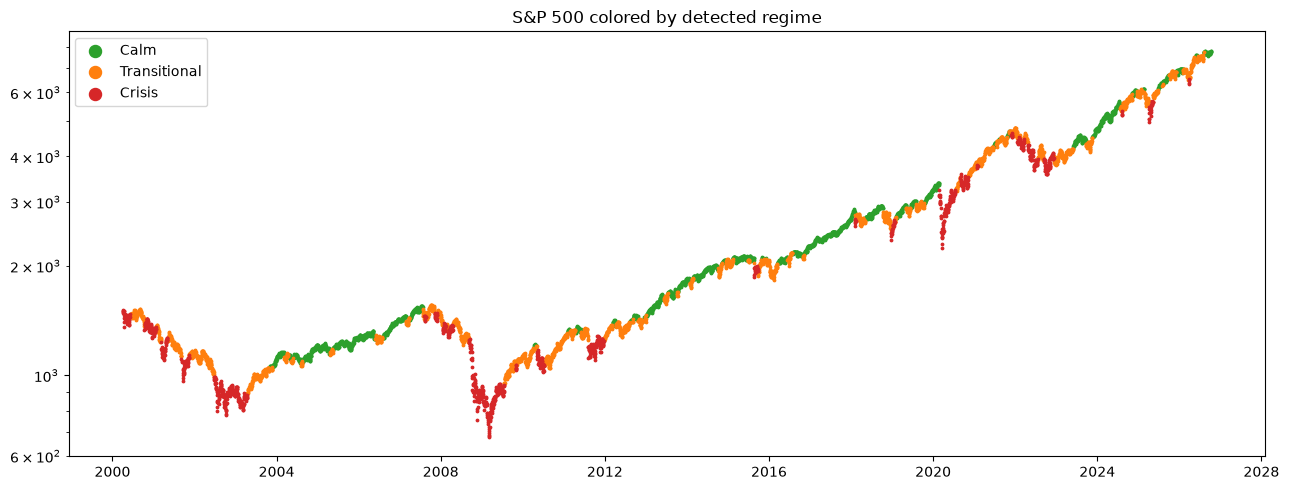

In [9]:
spx = df.loc[feats.index, "spx"]
color_map = {"Calm": "tab:green", "Transitional": "tab:orange", "Crisis": "tab:red"}

fig, ax = plt.subplots(figsize=(13, 5))
for name in ["Calm", "Transitional", "Crisis"]:
    mask = (regimes == name).values
    ax.scatter(spx.index[mask], spx[mask], s=3, color=color_map[name], label=name)

ax.set_yscale("log")
ax.set_title("S&P 500 colored by detected regime")
ax.legend(markerscale=5)
plt.tight_layout()
plt.savefig("../results/figures/regimes_hero.png", dpi=150)
plt.show()